# Notebook 5 - Advanced Models (XGBoost & LightGBM)

This notebook develops and evaluates XGBoost and LightGBM regression models for predicting residential property close prices.

The workflow uses chronological, leakage-aware training, validation, and testing datasets. Each hyperparameter combination is trained on the training period and evaluated on the separate validation month. After the final configuration is selected, the model is retrained using the combined training and validation datasets and evaluated once on the untouched testing month using R², MAE, MAPE, MdAPE, and RMSE.

## Advanced Model Summary

- Evaluated XGBoost and LightGBM using the same chronological training, validation, and testing datasets.
- Compared 27 hyperparameter combinations for each advanced model using only the validation month.
- XGBoost improved from validation R² 0.8678 in Version A to 0.9026 in Version B; Version C achieved test R² 0.9009.
- LightGBM improved from validation R² 0.8527 in Version A to 0.9037 in Version B; Version C achieved test R² 0.9060.
- Final models were retrained using training plus validation only after their parameters were frozen.
- LightGBM produced the strongest final test R², MAE, MAPE, and RMSE, while Random Forest retained the lowest MdAPE.

## Setup & Load Data

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
import time
from pathlib import Path
# Machine Learning
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
# Evaluation
from sklearn.metrics import (r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error)
# Plot
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Number of historical months used for training
TRAIN_MONTHS = 30

In [3]:
# Load csv files into dataframe
data_dir = Path("../data/cleaned_full")
paths = {
    "train_encoded": data_dir / f"train_encoded_{TRAIN_MONTHS}m.csv",
    "validation_encoded": data_dir / f"validation_encoded_{TRAIN_MONTHS}m.csv",
    "test_encoded": data_dir / f"test_encoded_{TRAIN_MONTHS}m.csv",
}
dfs = {
    name: pd.read_csv(path, low_memory = False)
    for name, path in paths.items()
}
train_encoded_df = dfs["train_encoded"]
validation_encoded_df = dfs["validation_encoded"]
test_encoded_df = dfs["test_encoded"]

# Read the retained transaction periods for an exact split summary
period_source = pd.read_csv(
    data_dir / f"cleaned_crmls_{TRAIN_MONTHS}m.csv",
    usecols = ["ClosePeriod"]
)
available_periods = pd.PeriodIndex(
    period_source["ClosePeriod"].dropna().astype(str),
    freq = "M"
).unique().sort_values()
test_period = available_periods.max()
validation_period = test_period - 1
training_periods = available_periods[available_periods < validation_period]

print(
    f"Training: {training_periods.min()} to {training_periods.max()} "
    f"({len(training_periods)} months)"
)
print(f"Validation: {validation_period} (1 month)")
print(f"Test: {test_period} (1 month)")

Training: 2023-11 to 2026-04 (30 months)
Validation: 2026-05 (1 month)
Test: 2026-06 (1 month)


In [4]:
print("Training Set shape:", train_encoded_df.shape)
print("Validation Set shape:", validation_encoded_df.shape)
print("Test Set shape:", test_encoded_df.shape)

Training Set shape: (317384, 128)
Validation Set shape: (11646, 128)
Test Set shape: (12442, 128)


## Prepare Features and Target

In [5]:
# Training set
x_train = train_encoded_df.drop(columns = ["ClosePrice"])
y_train = train_encoded_df["ClosePrice"]
# Validation set - used only for model/hyperparameter selection
x_validation = validation_encoded_df.drop(columns = ["ClosePrice"])
y_validation = validation_encoded_df["ClosePrice"]
# Test set
x_test = test_encoded_df.drop(columns = ["ClosePrice"])
y_test = test_encoded_df["ClosePrice"]

In [6]:
print(x_train.shape)
print(x_validation.shape)
print(x_test.shape)

(317384, 127)
(11646, 127)
(12442, 127)


## Model-Selection Training Target Summary

In [7]:
target_summary = y_train.describe().reset_index()
target_summary.columns = ["Statistic", "ClosePrice"]
def format_close_price(row):
    if row["Statistic"] == "count":
        return f"{row['ClosePrice']:,.0f}"
    else:
        return f"${row['ClosePrice']:,.2f}"
target_summary["ClosePrice"] = target_summary.apply(format_close_price, axis = 1)
target_summary.style.hide(axis = "index")

Statistic,ClosePrice
count,"317,384"
mean,"$1,189,808.79"
std,"$945,845.86"
min,"$189,000.00"
25%,"$620,000.00"
50%,"$887,000.00"
75%,"$1,415,000.00"
max,"$8,200,000.00"


## XGBoost

### Build Base Model

In [8]:
# Settings shared by every candidate model
xgb_common_params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1
}

### XGBoost A - Baseline

In [9]:
baseline_model = XGBRegressor(
    **xgb_common_params
)
baseline_model.fit(x_train, y_train)
baseline_valid_predictions = baseline_model.predict(x_validation)

In [10]:
def evaluation(y_test, y_pred):
    # R-squared
    r2 = r2_score(y_test, y_pred)
    # Other results
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    rmse = root_mean_squared_error(y_test, y_pred)
    return r2, mae, mape, mdape, rmse

In [11]:
baseline_r2, baseline_mae, baseline_mape, baseline_mdape, baseline_rmse = evaluation(y_validation, baseline_valid_predictions)

In [12]:
# Organize Results to dataframe
baseline_model_results = pd.DataFrame({
    "Version": ["XGBoost A"],
    "Model": ["Baseline XGBoost Regressor"],
    "Evaluation Set": ["Validation"],
    "R²": [baseline_r2],
    "MAE": [baseline_mae],
    "MAPE (%)": [baseline_mape],
    "MdAPE (%)": [baseline_mdape],
    "RMSE": [baseline_rmse]
})
# Convert to Dataframe
baseline_model_results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Version,Model,Evaluation Set,R²,MAE,MAPE (%),MdAPE (%),RMSE
XGBoost A,Baseline XGBoost Regressor,Validation,0.8678,"$198,103.15",15.7776%,11.3324%,"$355,429.73"


### XGBoost B - Hyperparameter Tuning

#### **Hyperparameter Search Space**

The search space below evaluates a focused set of values for the three Week 7 hyperparameters. Every combination is fitted on the training period and scored on the same held-out validation month.

The search evaluates:

- `max_depth`: controls the maximum depth of each tree.
- `learning_rate`: controls how strongly each new tree contributes to the model.
- `n_estimators`: controls the total number of boosting trees.

A total of 27 parameter combinations are evaluated. The testing month is not used during this search.

In [13]:
param_grid = {
    "max_depth": [7, 8, 9],
    "learning_rate": [0.08, 0.1, 0.12],
    "n_estimators": [900, 1200, 1500]
}

In [14]:
n_combinations = (
    len(param_grid["max_depth"])
    * len(param_grid["learning_rate"])
    * len(param_grid["n_estimators"])
)
print(f"Parameter combinations to evaluate: {n_combinations}")

Parameter combinations to evaluate: 27


#### **Hyperparameter Tuning**

Each candidate model is fitted using `x_train` and `y_train`, then evaluated using `x_validation` and `y_validation`. Validation R² is the primary selection metric; MAE, MdAPE, RMSE, and fitting time are recorded for comparison.

The testing dataset remains untouched during model selection. This preserves an unbiased final estimate of model performance.

In [15]:
tuning_results = []
for max_depth in param_grid["max_depth"]:
    for learning_rate in param_grid["learning_rate"]:
        for n_estimators in param_grid["n_estimators"]:
            candidate_model = XGBRegressor(
                max_depth = max_depth,
                learning_rate = learning_rate,
                n_estimators = n_estimators,
                **xgb_common_params
            )

            start_time = time.perf_counter()
            candidate_model.fit(x_train, y_train)
            fit_time = time.perf_counter() - start_time

            validation_predictions = candidate_model.predict(x_validation)
            validation_mape = mean_absolute_percentage_error(
                y_validation, validation_predictions
            ) * 100
            validation_mdape = np.median(
                np.abs((y_validation - validation_predictions) / y_validation)
            ) * 100

            tuning_results.append({
                "Max Depth": max_depth,
                "Learning Rate": learning_rate,
                "N Estimators": n_estimators,
                "Validation R²": r2_score(y_validation, validation_predictions),
                "Validation MAE": mean_absolute_error(y_validation, validation_predictions),
                "Validation MAPE (%)": validation_mape,
                "Validation MdAPE (%)": validation_mdape,
                "Validation RMSE": root_mean_squared_error(y_validation, validation_predictions),
                "Fit Time (s)": fit_time
            })

            print(
                f"Completed {len(tuning_results):>2}/{n_combinations}: "
                f"depth={max_depth}, learning_rate={learning_rate}, "
                f"n_estimators={n_estimators}"
            )

print("Validation tuning completed!")

Completed  1/27: depth=7, learning_rate=0.08, n_estimators=900
Completed  2/27: depth=7, learning_rate=0.08, n_estimators=1200
Completed  3/27: depth=7, learning_rate=0.08, n_estimators=1500
Completed  4/27: depth=7, learning_rate=0.1, n_estimators=900
Completed  5/27: depth=7, learning_rate=0.1, n_estimators=1200
Completed  6/27: depth=7, learning_rate=0.1, n_estimators=1500
Completed  7/27: depth=7, learning_rate=0.12, n_estimators=900
Completed  8/27: depth=7, learning_rate=0.12, n_estimators=1200
Completed  9/27: depth=7, learning_rate=0.12, n_estimators=1500
Completed 10/27: depth=8, learning_rate=0.08, n_estimators=900
Completed 11/27: depth=8, learning_rate=0.08, n_estimators=1200
Completed 12/27: depth=8, learning_rate=0.08, n_estimators=1500
Completed 13/27: depth=8, learning_rate=0.1, n_estimators=900
Completed 14/27: depth=8, learning_rate=0.1, n_estimators=1200
Completed 15/27: depth=8, learning_rate=0.1, n_estimators=1500
Completed 16/27: depth=8, learning_rate=0.12, n_est

In [16]:
tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by = ["Validation R²", "Validation RMSE"],
    ascending = [False, True]
).reset_index(drop = True)

# Treat candidates within this validation R² distance as practically tied.
R2_TOLERANCE = 0.001
best_validation_r2 = tuning_results_df["Validation R²"].max()
tuning_results_df["Near Best"] = (
    tuning_results_df["Validation R²"]
    >= best_validation_r2 - R2_TOLERANCE
)

near_best_models = tuning_results_df[
    tuning_results_df["Near Best"]
].copy()

selected_xgb_row = near_best_models.sort_values(
    by = ["Fit Time (s)", "Max Depth", "N Estimators"],
    ascending = [True, True, True]
).iloc[0]

selection_reason = (
    "Selected the fastest model within 0.001 validation R² of the "
    "best candidate. Lower model complexity was used as a tie-breaker."
)

best_xgb_params = {
    "max_depth": int(selected_xgb_row["Max Depth"]),
    "learning_rate": float(selected_xgb_row["Learning Rate"]),
    "n_estimators": int(selected_xgb_row["N Estimators"])
}

display(
    tuning_results_df.style.format({
        "Learning Rate": "{:.2f}",
        "Validation R²": "{:.4f}",
        "Validation MAE": "${:,.2f}",
        "Validation MAPE (%)": "{:.4f}%",
        "Validation MdAPE (%)": "{:.4f}%",
        "Validation RMSE": "${:,.2f}",
        "Fit Time (s)": "{:.2f}"
    }).hide(axis = "index")
)

Max Depth,Learning Rate,N Estimators,Validation R²,Validation MAE,Validation MAPE (%),Validation MdAPE (%),Validation RMSE,Fit Time (s),Near Best
8,0.12,1500,0.9032,"$156,643.74",11.8384%,7.9899%,"$304,164.85",21.28,True
9,0.10,1500,0.9031,"$155,923.61",11.7551%,7.7482%,"$304,290.55",25.48,True
9,0.08,1500,0.9027,"$155,423.78",11.7077%,7.8097%,"$304,890.78",25.54,True
9,0.10,1200,0.9027,"$156,584.74",11.8093%,7.8249%,"$304,962.92",20.53,True
8,0.12,1200,0.9026,"$157,473.04",11.9034%,8.0322%,"$305,146.10",17.24,True
9,0.08,1200,0.9024,"$156,120.91",11.7737%,7.8456%,"$305,356.34",20.51,True
8,0.10,1500,0.9021,"$157,738.99",11.9979%,7.9774%,"$305,857.42",21.54,False
8,0.12,900,0.9019,"$158,452.06",12.0102%,8.1398%,"$306,244.29",13.32,False
9,0.10,900,0.9018,"$157,548.46",11.8859%,7.8796%,"$306,321.15",15.71,False
7,0.12,1500,0.9014,"$160,083.45",12.2507%,8.2923%,"$306,966.17",18.47,False


#### Validation R² Heatmaps

Each panel fixes one `learning_rate`. Within each panel, rows represent `max_depth`, columns represent `n_estimators`, and every cell displays the corresponding validation R² score. All panels share the same color scale so their colors can be compared directly.

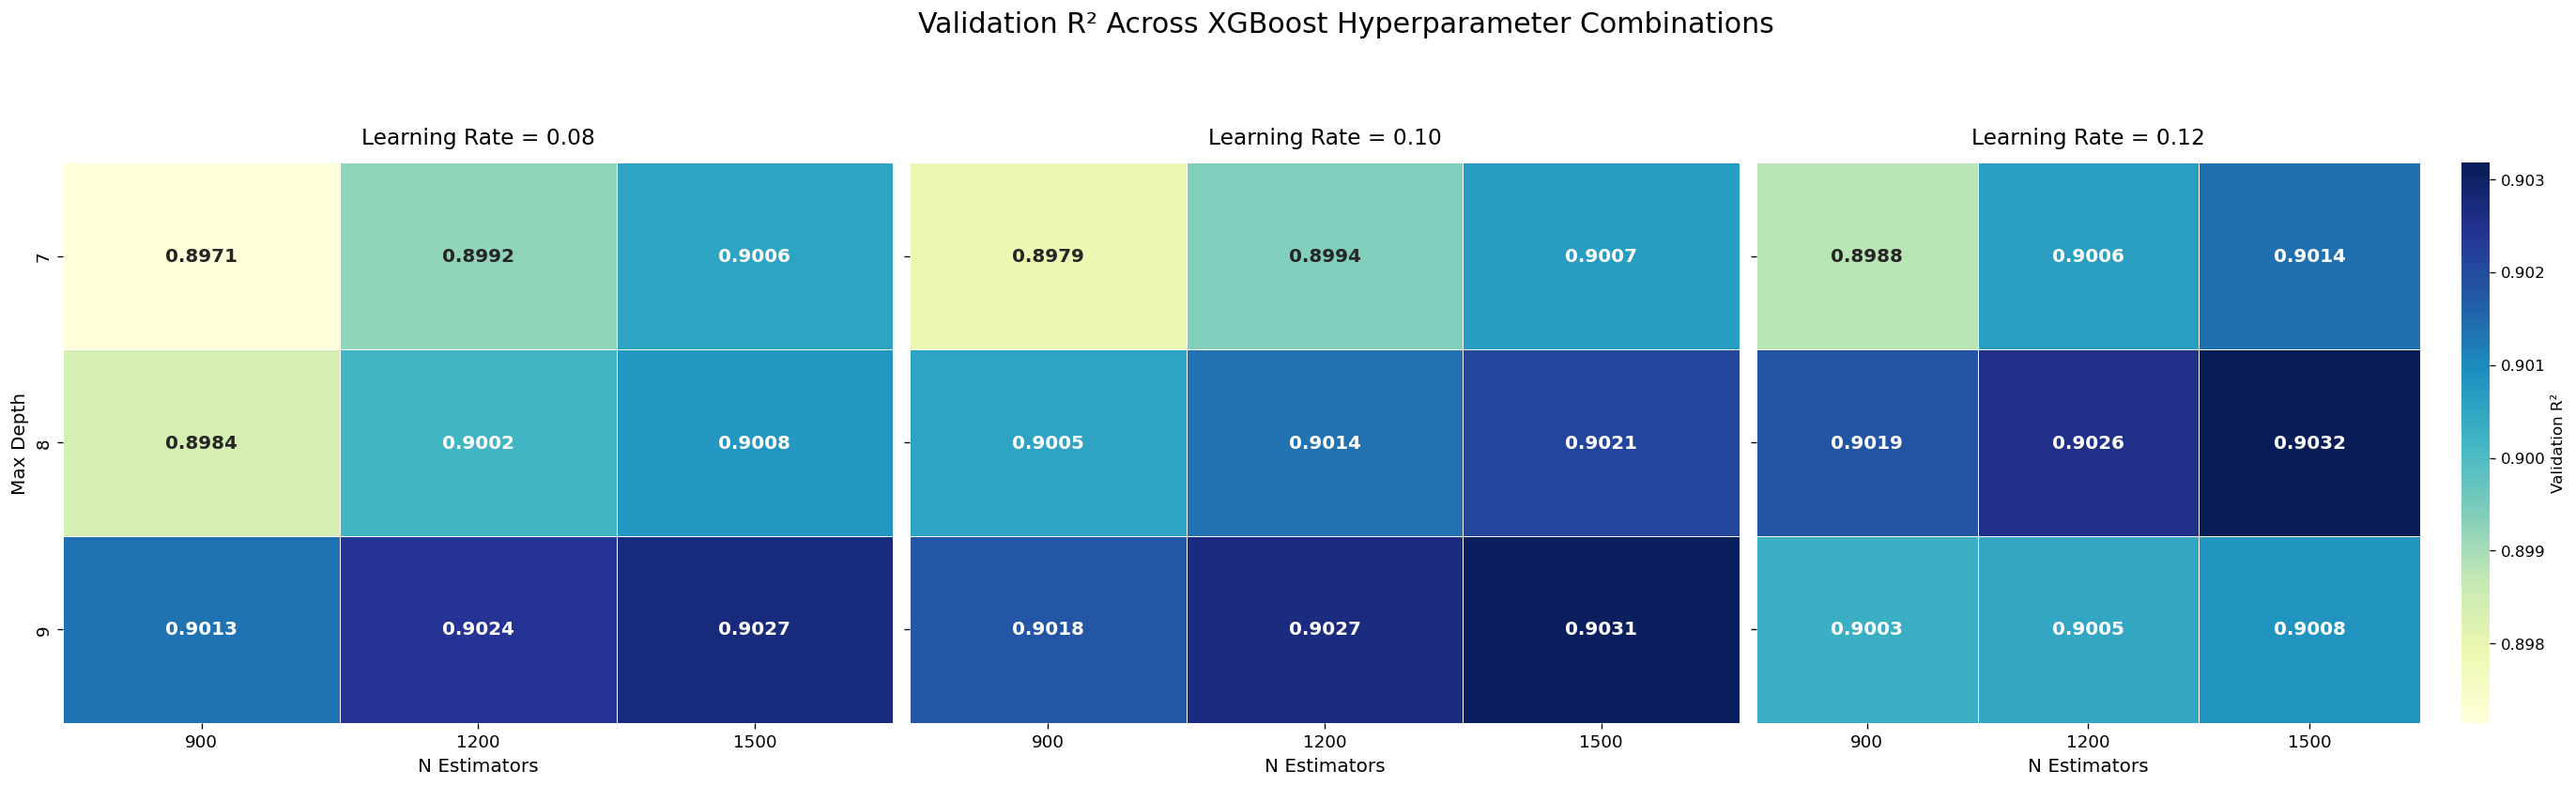

In [17]:
learning_rates = sorted(tuning_results_df["Learning Rate"].unique())
r2_color_min = tuning_results_df["Validation R²"].min()
r2_color_max = tuning_results_df["Validation R²"].max()

fig, axes = plt.subplots(
    1,
    len(learning_rates),
    figsize = (24, 7),
    dpi = 120,
    sharey = True
)

for panel_index, (ax, learning_rate) in enumerate(zip(axes, learning_rates)):
    heatmap_data = (
        tuning_results_df[
            tuning_results_df["Learning Rate"] == learning_rate
        ]
        .pivot(
            index = "Max Depth",
            columns = "N Estimators",
            values = "Validation R²"
        )
        .sort_index()
        .sort_index(axis = 1)
    )

    sns.heatmap(
        heatmap_data,
        annot = True,
        fmt = ".4f",
        annot_kws = {"size": 12, "weight": "bold"},
        cmap = "YlGnBu",
        vmin = r2_color_min,
        vmax = r2_color_max,
        linewidths = 0.5,
        linecolor = "white",
        cbar = panel_index == len(learning_rates) - 1,
        cbar_kws = {"label": "Validation R²"},
        ax = ax
    )

    ax.set_title(
        f"Learning Rate = {learning_rate:.2f}",
        fontsize = 14,
        pad = 12
    )
    ax.set_xlabel("N Estimators", fontsize = 12)
    ax.set_ylabel(
        "Max Depth" if panel_index == 0 else "",
        fontsize = 12
    )
    ax.tick_params(axis = "both", labelsize = 11)

fig.suptitle(
    "Validation R² Across XGBoost Hyperparameter Combinations",
    fontsize = 18,
    y = 0.99
)
plt.tight_layout(rect = [0, 0, 0.97, 0.92])
plt.show()

### Final Parameter Selection

Selecting the configuration with the highest validation score may not provide a meaningful practical advantage when several models perform almost identically.

A model is classified as near-best when its validation R² is within 0.001 of the highest observed validation score. Among these near-best models, the configuration with the shortest fitting time is selected.

If multiple candidates have similar fitting times, lower model complexity is used as a tie-breaker. The validation month is used only for model selection, and the testing month remains untouched until the final model is frozen.

The highest validation R² was 0.9032 for `max_depth = 8`, `learning_rate = 0.12`, and `n_estimators = 1500`. The selected configuration used `max_depth = 8`, `learning_rate = 0.12`, and `n_estimators = 1200`, achieving validation R² of 0.9026. Its R² was only 0.0006 lower while fitting in 17.35 seconds instead of 21.30 seconds, approximately 18.5% faster in this run.

In [18]:
print(f"Best Validation R²: {best_validation_r2:.4f}")
print(f"R² tolerance: {R2_TOLERANCE:.4f}")
print(selection_reason)
print("Selected XGBoost parameters:", best_xgb_params)

Best Validation R²: 0.9032
R² tolerance: 0.0010
Selected the fastest model within 0.001 validation R² of the best candidate. Lower model complexity was used as a tie-breaker.
Selected XGBoost parameters: {'max_depth': 8, 'learning_rate': 0.12, 'n_estimators': 1200}


In [19]:
# Add the selected tuned model and display cumulative Version A-B results
version_b_result = pd.DataFrame({
    "Version": ["XGBoost B"],
    "Model": ["Tuned XGBoost Regressor"],
    "Evaluation Set": ["Validation"],
    "R²": [selected_xgb_row["Validation R²"]],
    "MAE": [selected_xgb_row["Validation MAE"]],
    "MAPE (%)": [selected_xgb_row["Validation MAPE (%)"]],
    "MdAPE (%)": [selected_xgb_row["Validation MdAPE (%)"]],
    "RMSE": [selected_xgb_row["Validation RMSE"]]
})

xgb_ab_results = pd.concat(
    [baseline_model_results, version_b_result],
    ignore_index = True
)

xgb_ab_results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Version,Model,Evaluation Set,R²,MAE,MAPE (%),MdAPE (%),RMSE
XGBoost A,Baseline XGBoost Regressor,Validation,0.8678,"$198,103.15",15.7776%,11.3324%,"$355,429.73"
XGBoost B,Tuned XGBoost Regressor,Validation,0.9026,"$157,473.04",11.9034%,8.0322%,"$305,146.10"


## XGBoost C — Final Model and Test Evaluation

After hyperparameter selection is complete, the selected XGBoost configuration (`max_depth = 8`, `learning_rate = 0.12`, and `n_estimators = 1200`) is retrained using the combined training and validation datasets.

The validation data can now be included because it is no longer being used to make model-selection decisions. The untouched testing month is reserved exclusively for the final evaluation.

In [20]:
final_xgb = XGBRegressor(
    **xgb_common_params,
    **best_xgb_params
)

In [21]:
# Combine training and validation only after hyperparameters are frozen
x_train_final = pd.concat([x_train, x_validation], ignore_index = True)
y_train_final = pd.concat([y_train, y_validation], ignore_index = True)

final_xgb.fit(x_train_final, y_train_final)
print("Final XGBoost training on train + validation completed.")

Final XGBoost training on train + validation completed.


In [22]:
y_pred = final_xgb.predict(x_test)

## XGBoost Feature Importance

In [23]:
xgb_feature_importance = pd.DataFrame({"Feature": x_train_final.columns, "Importance": final_xgb.feature_importances_})\
    .sort_values("Importance", ascending = False).head(15)
xgb_feature_importance

,Feature,Importance
80,CountyOrParish_San Diego,0.109058
10,BathroomsTotalInteger,0.098927
86,CountyOrParish_Santa Clara,0.087819
79,CountyOrParish_San Bernardino,0.064142
76,CountyOrParish_Riverside,0.061374
126,Levels_Unknown,0.054312
121,Flooring_Wood,0.049447
84,CountyOrParish_San Mateo,0.040883
70,CountyOrParish_Orange,0.035526
6,LivingArea,0.031506


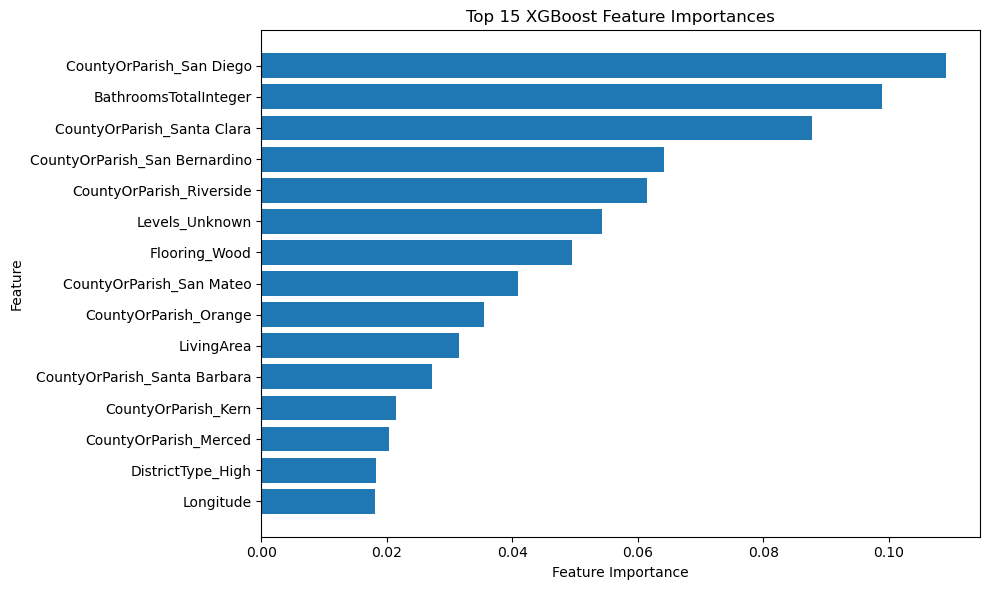

In [24]:
plt.figure(figsize = (10, 6))
plt.barh(xgb_feature_importance["Feature"][::-1], xgb_feature_importance["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

## Evaluate Model Performance

The final XGBoost model is evaluated on the untouched testing dataset using:

- **R²:** proportion of variation in close prices explained by the model.
- **MAE:** average absolute prediction error in dollars.
- **MAPE:** average absolute percentage prediction error.
- **MdAPE:** median absolute percentage prediction error, which is less sensitive to extreme percentage errors.
- **RMSE:** root mean squared error, which places greater emphasis on large prediction errors.

In [25]:
r2, mae, mape, mdape, rmse = evaluation(y_test, y_pred)

## XGBoost Version Results

| Version | Model | Evaluation Set | R² | MAE | MAPE (%) | MdAPE (%) | RMSE |
|---|---|---|---:|---:|---:|---:|---:|
| XGBoost A | Baseline XGBoost Regressor | Validation | 0.8678 | USD 198,103.15 | 15.7776% | 11.3324% | USD 355,429.73 |
| XGBoost B | Tuned XGBoost Regressor | Validation | 0.9026 | USD 157,473.04 | 11.9034% | 8.0322% | USD 305,146.10 |
| XGBoost C | Final XGBoost Regressor | Test | 0.9009 | USD 160,000.81 | 12.5889% | 8.3710% | USD 309,013.08 |

Hyperparameter tuning substantially improved every validation metric from Version A to Version B. Version C remained close to Version B despite being evaluated on a later, untouched test month: R² decreased by 0.0017, while MAE and RMSE increased by USD 2,527.77 and USD 3,866.98, respectively.

In [26]:
# Add the final test result and display cumulative Version A-C results
version_c_result = pd.DataFrame({
    "Version": ["XGBoost C"],
    "Model": ["Final XGBoost Regressor"],
    "Evaluation Set": ["Test"],
    "R²": [r2],
    "MAE": [mae],
    "MAPE (%)": [mape],
    "MdAPE (%)": [mdape],
    "RMSE": [rmse]
})

xgb_abc_results = pd.concat(
    [xgb_ab_results, version_c_result],
    ignore_index = True
)

xgb_abc_results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Version,Model,Evaluation Set,R²,MAE,MAPE (%),MdAPE (%),RMSE
XGBoost A,Baseline XGBoost Regressor,Validation,0.8678,"$198,103.15",15.7776%,11.3324%,"$355,429.73"
XGBoost B,Tuned XGBoost Regressor,Validation,0.9026,"$157,473.04",11.9034%,8.0322%,"$305,146.10"
XGBoost C,Final XGBoost Regressor,Test,0.9009,"$160,000.81",12.5889%,8.3710%,"$309,013.08"


## Actual vs Predicted Plot

### XGBoost

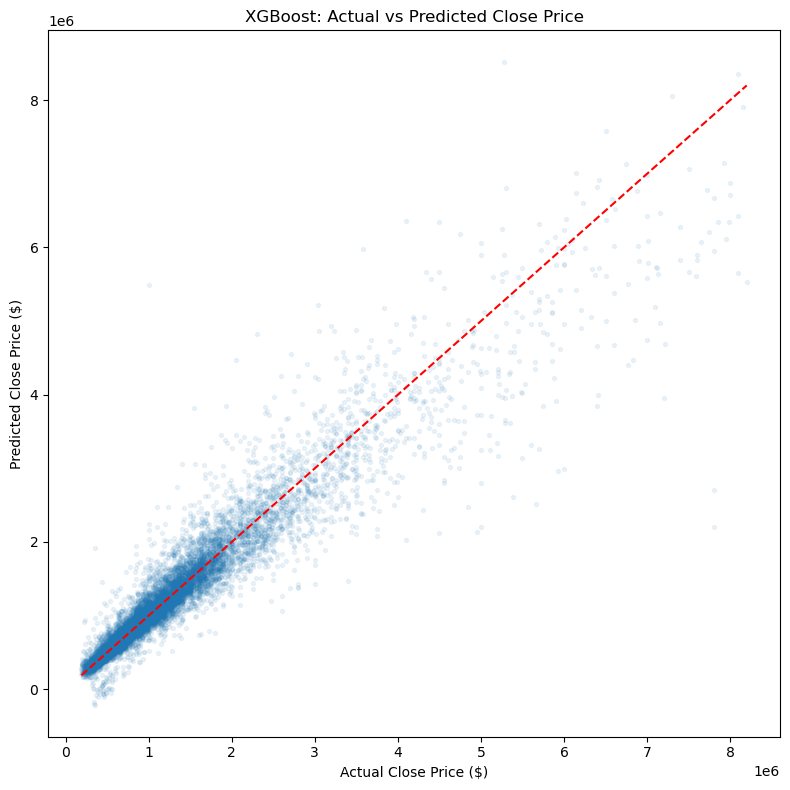

In [27]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred, alpha = 0.08, s = 8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "red", linestyle = "--")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("XGBoost: Actual vs Predicted Close Price")
plt.tight_layout()
plt.show()

## LightGBM

LightGBM is evaluated with the same leakage-aware A/B/C structure as XGBoost. Versions A and B use the validation month. After the Version B parameters are frozen, Version C is retrained on training plus validation and evaluated once on the untouched test month.

### LightGBM A - Baseline

In [28]:
# Settings shared by every LightGBM model
lgbm_common_params = {
    "objective": "regression",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

lgbm_baseline_model = LGBMRegressor(
    num_leaves = 31,
    learning_rate = 0.10,
    n_estimators = 100,
    **lgbm_common_params
)
lgbm_baseline_model.fit(x_train, y_train)
lgbm_baseline_valid_predictions = lgbm_baseline_model.predict(x_validation)

(
    lgbm_baseline_r2,
    lgbm_baseline_mae,
    lgbm_baseline_mape,
    lgbm_baseline_mdape,
    lgbm_baseline_rmse
) = evaluation(y_validation, lgbm_baseline_valid_predictions)

In [29]:
lgbm_a_results = pd.DataFrame({
    "Version": ["LightGBM A"],
    "Model": ["Baseline LightGBM Regressor"],
    "Evaluation Set": ["Validation"],
    "R²": [lgbm_baseline_r2],
    "MAE": [lgbm_baseline_mae],
    "MAPE (%)": [lgbm_baseline_mape],
    "MdAPE (%)": [lgbm_baseline_mdape],
    "RMSE": [lgbm_baseline_rmse]
})
lgbm_a_results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Version,Model,Evaluation Set,R²,MAE,MAPE (%),MdAPE (%),RMSE
LightGBM A,Baseline LightGBM Regressor,Validation,0.8527,"$211,672.36",17.1957%,12.2529%,"$375,225.27"


### LightGBM B - Hyperparameter Tuning

The search evaluates 27 combinations of `num_leaves`, `learning_rate`, and `n_estimators`. Every candidate is fitted on the training period and evaluated on the validation month; the test month is not used for model selection.

In [30]:
lgbm_param_grid = {
    "num_leaves": [31, 63, 127],
    "learning_rate": [0.03, 0.05, 0.08],
    "n_estimators": [500, 900, 1300]
}

lgbm_n_combinations = (
    len(lgbm_param_grid["num_leaves"])
    * len(lgbm_param_grid["learning_rate"])
    * len(lgbm_param_grid["n_estimators"])
)
print(f"LightGBM parameter combinations to evaluate: {lgbm_n_combinations}")

LightGBM parameter combinations to evaluate: 27


In [31]:
lgbm_tuning_results = []

for num_leaves in lgbm_param_grid["num_leaves"]:
    for learning_rate in lgbm_param_grid["learning_rate"]:
        for n_estimators in lgbm_param_grid["n_estimators"]:
            lgbm_candidate_model = LGBMRegressor(
                num_leaves = num_leaves,
                learning_rate = learning_rate,
                n_estimators = n_estimators,
                **lgbm_common_params
            )

            start_time = time.perf_counter()
            lgbm_candidate_model.fit(x_train, y_train)
            fit_time = time.perf_counter() - start_time

            lgbm_validation_predictions = lgbm_candidate_model.predict(x_validation)
            lgbm_validation_metrics = evaluation(
                y_validation,
                lgbm_validation_predictions
            )

            lgbm_tuning_results.append({
                "Num Leaves": num_leaves,
                "Learning Rate": learning_rate,
                "N Estimators": n_estimators,
                "Validation R²": lgbm_validation_metrics[0],
                "Validation MAE": lgbm_validation_metrics[1],
                "Validation MAPE (%)": lgbm_validation_metrics[2],
                "Validation MdAPE (%)": lgbm_validation_metrics[3],
                "Validation RMSE": lgbm_validation_metrics[4],
                "Fit Time (s)": fit_time
            })

            print(
                f"Completed {len(lgbm_tuning_results):>2}/{lgbm_n_combinations}: "
                f"num_leaves={num_leaves}, learning_rate={learning_rate}, "
                f"n_estimators={n_estimators}"
            )

print("LightGBM validation tuning completed!")

Completed  1/27: num_leaves=31, learning_rate=0.03, n_estimators=500
Completed  2/27: num_leaves=31, learning_rate=0.03, n_estimators=900
Completed  3/27: num_leaves=31, learning_rate=0.03, n_estimators=1300
Completed  4/27: num_leaves=31, learning_rate=0.05, n_estimators=500
Completed  5/27: num_leaves=31, learning_rate=0.05, n_estimators=900
Completed  6/27: num_leaves=31, learning_rate=0.05, n_estimators=1300
Completed  7/27: num_leaves=31, learning_rate=0.08, n_estimators=500
Completed  8/27: num_leaves=31, learning_rate=0.08, n_estimators=900
Completed  9/27: num_leaves=31, learning_rate=0.08, n_estimators=1300
Completed 10/27: num_leaves=63, learning_rate=0.03, n_estimators=500
Completed 11/27: num_leaves=63, learning_rate=0.03, n_estimators=900
Completed 12/27: num_leaves=63, learning_rate=0.03, n_estimators=1300
Completed 13/27: num_leaves=63, learning_rate=0.05, n_estimators=500
Completed 14/27: num_leaves=63, learning_rate=0.05, n_estimators=900
Completed 15/27: num_leaves=63

In [32]:
lgbm_tuning_results_df = pd.DataFrame(lgbm_tuning_results).sort_values(
    by = ["Validation R²", "Validation RMSE"],
    ascending = [False, True]
).reset_index(drop = True)

lgbm_best_validation_r2 = lgbm_tuning_results_df["Validation R²"].max()
lgbm_tuning_results_df["Near Best"] = (
    lgbm_tuning_results_df["Validation R²"]
    >= lgbm_best_validation_r2 - R2_TOLERANCE
)
lgbm_near_best_models = lgbm_tuning_results_df[
    lgbm_tuning_results_df["Near Best"]
].copy()
lgbm_selected_row = lgbm_near_best_models.sort_values(
    by = ["Fit Time (s)", "Num Leaves", "N Estimators"],
    ascending = [True, True, True]
).iloc[0]

best_lgbm_params = {
    "num_leaves": int(lgbm_selected_row["Num Leaves"]),
    "learning_rate": float(lgbm_selected_row["Learning Rate"]),
    "n_estimators": int(lgbm_selected_row["N Estimators"])
}

display(
    lgbm_tuning_results_df.style.format({
        "Learning Rate": "{:.2f}",
        "Validation R²": "{:.4f}",
        "Validation MAE": "${:,.2f}",
        "Validation MAPE (%)": "{:.4f}%",
        "Validation MdAPE (%)": "{:.4f}%",
        "Validation RMSE": "${:,.2f}",
        "Fit Time (s)": "{:.2f}"
    }).hide(axis = "index")
)

Num Leaves,Learning Rate,N Estimators,Validation R²,Validation MAE,Validation MAPE (%),Validation MdAPE (%),Validation RMSE,Fit Time (s),Near Best
127,0.08,1300,0.9046,"$157,370.86",12.0560%,8.1040%,"$301,895.78",35.04,True
127,0.05,1300,0.9045,"$158,611.87",12.1701%,8.3494%,"$302,075.63",36.00,True
127,0.08,900,0.9037,"$159,114.15",12.2673%,8.3805%,"$303,347.21",25.04,True
63,0.08,1300,0.9035,"$160,768.24",12.3742%,8.5726%,"$303,670.10",19.98,False
127,0.05,900,0.9026,"$161,596.79",12.4954%,8.6242%,"$305,129.55",25.05,False
127,0.03,1300,0.9023,"$162,371.39",12.5741%,8.6772%,"$305,538.40",37.09,False
63,0.05,1300,0.9018,"$163,752.54",12.7449%,8.9134%,"$306,401.41",20.28,False
63,0.08,900,0.9015,"$164,044.84",12.7334%,8.9250%,"$306,845.47",14.21,False
127,0.08,500,0.9012,"$163,223.50",12.7006%,8.7405%,"$307,230.27",14.40,False
127,0.03,900,0.8998,"$165,868.99",12.9163%,8.9615%,"$309,441.60",25.53,False


#### LightGBM Validation R² Heatmaps

Each panel fixes one `learning_rate`. Rows represent `num_leaves`, columns represent `n_estimators`, and every cell displays its validation R² score. All panels share the same color scale so their colors can be compared directly.

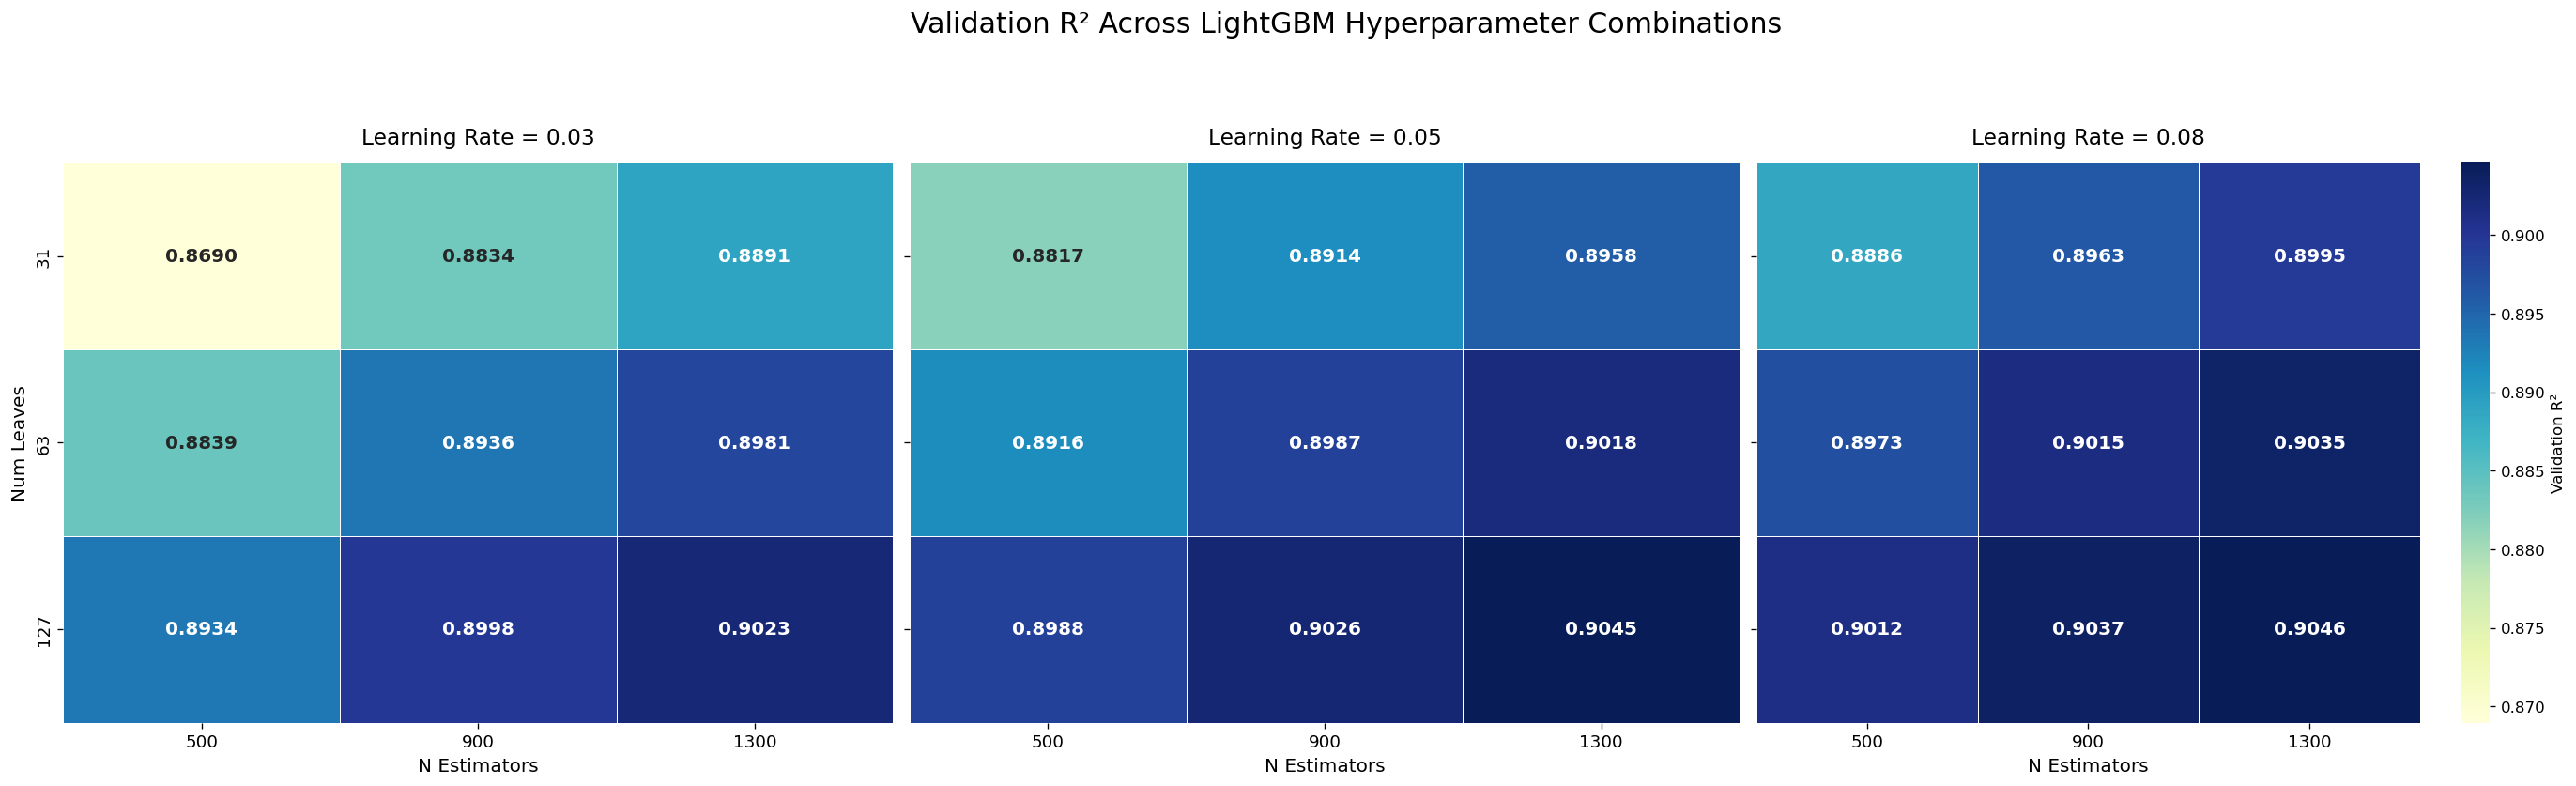

In [33]:
lgbm_learning_rates = sorted(lgbm_tuning_results_df["Learning Rate"].unique())
lgbm_r2_color_min = lgbm_tuning_results_df["Validation R²"].min()
lgbm_r2_color_max = lgbm_tuning_results_df["Validation R²"].max()

fig, axes = plt.subplots(
    1,
    len(lgbm_learning_rates),
    figsize = (24, 7),
    dpi = 120,
    sharey = True
)

for panel_index, (ax, learning_rate) in enumerate(
    zip(axes, lgbm_learning_rates)
):
    lgbm_heatmap_data = (
        lgbm_tuning_results_df[
            lgbm_tuning_results_df["Learning Rate"] == learning_rate
        ]
        .pivot(
            index = "Num Leaves",
            columns = "N Estimators",
            values = "Validation R²"
        )
        .sort_index()
        .sort_index(axis = 1)
    )

    sns.heatmap(
        lgbm_heatmap_data,
        annot = True,
        fmt = ".4f",
        annot_kws = {"size": 12, "weight": "bold"},
        cmap = "YlGnBu",
        vmin = lgbm_r2_color_min,
        vmax = lgbm_r2_color_max,
        linewidths = 0.5,
        linecolor = "white",
        cbar = panel_index == len(lgbm_learning_rates) - 1,
        cbar_kws = {"label": "Validation R²"},
        ax = ax
    )
    ax.set_title(
        f"Learning Rate = {learning_rate:.2f}",
        fontsize = 14,
        pad = 12
    )
    ax.set_xlabel("N Estimators", fontsize = 12)
    ax.set_ylabel(
        "Num Leaves" if panel_index == 0 else "",
        fontsize = 12
    )
    ax.tick_params(axis = "both", labelsize = 11)

fig.suptitle(
    "Validation R² Across LightGBM Hyperparameter Combinations",
    fontsize = 18,
    y = 0.99
)
plt.tight_layout(rect = [0, 0, 0.97, 0.92])
plt.show()

### LightGBM Final Parameter Selection

The highest validation R² was 0.9046 for `num_leaves = 127`, `learning_rate = 0.08`, and `n_estimators = 1300`. The selected configuration used the same `num_leaves` and `learning_rate` with 900 estimators, achieving validation R² of 0.9037. Its R² was only 0.0009 lower while fitting in 24.94 seconds instead of 34.91 seconds, approximately 28.6% faster in this run.

In [34]:
print(f"Best LightGBM Validation R²: {lgbm_best_validation_r2:.4f}")
print(f"R² tolerance: {R2_TOLERANCE:.4f}")
print("Selected LightGBM parameters:", best_lgbm_params)

lgbm_b_result = pd.DataFrame({
    "Version": ["LightGBM B"],
    "Model": ["Tuned LightGBM Regressor"],
    "Evaluation Set": ["Validation"],
    "R²": [lgbm_selected_row["Validation R²"]],
    "MAE": [lgbm_selected_row["Validation MAE"]],
    "MAPE (%)": [lgbm_selected_row["Validation MAPE (%)"]],
    "MdAPE (%)": [lgbm_selected_row["Validation MdAPE (%)"]],
    "RMSE": [lgbm_selected_row["Validation RMSE"]]
})
lgbm_ab_results = pd.concat(
    [lgbm_a_results, lgbm_b_result],
    ignore_index = True
)
lgbm_ab_results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Best LightGBM Validation R²: 0.9046
R² tolerance: 0.0010
Selected LightGBM parameters: {'num_leaves': 127, 'learning_rate': 0.08, 'n_estimators': 900}


Version,Model,Evaluation Set,R²,MAE,MAPE (%),MdAPE (%),RMSE
LightGBM A,Baseline LightGBM Regressor,Validation,0.8527,"$211,672.36",17.1957%,12.2529%,"$375,225.27"
LightGBM B,Tuned LightGBM Regressor,Validation,0.9037,"$159,114.15",12.2673%,8.3805%,"$303,347.21"


### LightGBM C - Final Model and Test Evaluation

After parameter selection is complete, the selected LightGBM configuration (`num_leaves = 127`, `learning_rate = 0.08`, and `n_estimators = 900`) is retrained on the combined training and validation datasets and evaluated once on the untouched test month.

In [35]:
final_lgbm = LGBMRegressor(
    **lgbm_common_params,
    **best_lgbm_params
)
final_lgbm.fit(x_train_final, y_train_final)
lgbm_test_predictions = final_lgbm.predict(x_test)
(
    lgbm_test_r2,
    lgbm_test_mae,
    lgbm_test_mape,
    lgbm_test_mdape,
    lgbm_test_rmse
) = evaluation(y_test, lgbm_test_predictions)

lgbm_c_result = pd.DataFrame({
    "Version": ["LightGBM C"],
    "Model": ["Final LightGBM Regressor"],
    "Evaluation Set": ["Test"],
    "R²": [lgbm_test_r2],
    "MAE": [lgbm_test_mae],
    "MAPE (%)": [lgbm_test_mape],
    "MdAPE (%)": [lgbm_test_mdape],
    "RMSE": [lgbm_test_rmse]
})
lgbm_abc_results = pd.concat(
    [lgbm_ab_results, lgbm_c_result],
    ignore_index = True
)
lgbm_abc_results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Version,Model,Evaluation Set,R²,MAE,MAPE (%),MdAPE (%),RMSE
LightGBM A,Baseline LightGBM Regressor,Validation,0.8527,"$211,672.36",17.1957%,12.2529%,"$375,225.27"
LightGBM B,Tuned LightGBM Regressor,Validation,0.9037,"$159,114.15",12.2673%,8.3805%,"$303,347.21"
LightGBM C,Final LightGBM Regressor,Test,0.9060,"$156,025.13",12.1622%,8.3320%,"$301,065.10"


### LightGBM Version Results

| Version | Model | Evaluation Set | R² | MAE | MAPE (%) | MdAPE (%) | RMSE |
|---|---|---|---:|---:|---:|---:|---:|
| LightGBM A | Baseline LightGBM Regressor | Validation | 0.8527 | USD 211,672.36 | 17.1957% | 12.2529% | USD 375,225.27 |
| LightGBM B | Tuned LightGBM Regressor | Validation | 0.9037 | USD 159,114.15 | 12.2673% | 8.3805% | USD 303,347.21 |
| LightGBM C | Final LightGBM Regressor | Test | 0.9060 | USD 156,025.13 | 12.1622% | 8.3320% | USD 301,065.10 |

Hyperparameter tuning substantially improved every validation metric from Version A to Version B. Version C remained stable on the later test month and slightly improved on Version B: R² increased by 0.0023, while MAE and RMSE decreased by USD 3,089.02 and USD 2,282.11, respectively.

### LightGBM Gain-Based Feature Importance

Gain importance measures the total split improvement attributed to each feature. It is descriptive and should not be interpreted as causal importance.

In [36]:
lgbm_gain_values = final_lgbm.booster_.feature_importance(
    importance_type = "gain"
)
lgbm_gain_total = lgbm_gain_values.sum()
lgbm_normalized_gain = (
    lgbm_gain_values / lgbm_gain_total
    if lgbm_gain_total > 0
    else lgbm_gain_values
)
lgbm_feature_importance = (
    pd.DataFrame({
        "Feature": x_train_final.columns,
        "Gain Importance": lgbm_normalized_gain
    })
    .sort_values("Gain Importance", ascending = False)
    .head(15)
)
lgbm_feature_importance.style.format({
    "Gain Importance": "{:.4%}"
}).hide(axis = "index")

Feature,Gain Importance
LivingArea,27.0571%
Longitude,16.9024%
Latitude,15.8010%
BathroomsTotalInteger,12.6687%
CountyOrParish_Santa Clara,4.1041%
Flooring_Wood,3.5836%
BathroomsPerBedroom,1.6898%
CountyOrParish_Orange,1.4049%
PropertyAge,1.3959%
YearBuilt,1.2965%


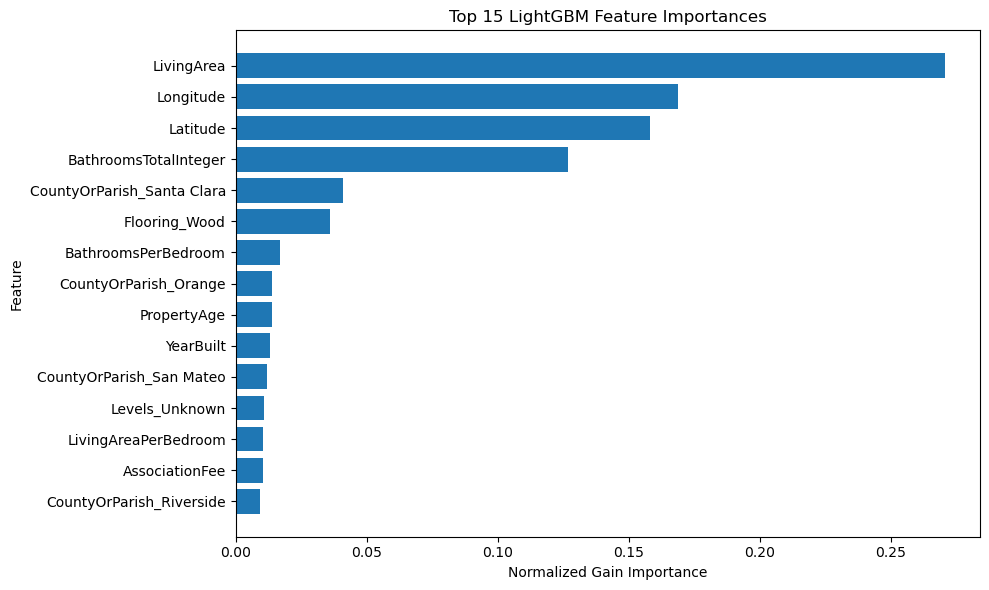

In [37]:
plt.figure(figsize = (10, 6))
plt.barh(
    lgbm_feature_importance["Feature"][::-1],
    lgbm_feature_importance["Gain Importance"][::-1]
)
plt.xlabel("Normalized Gain Importance")
plt.ylabel("Feature")
plt.title("Top 15 LightGBM Feature Importances")
plt.tight_layout()
plt.show()

### LightGBM Actual vs Predicted Plot

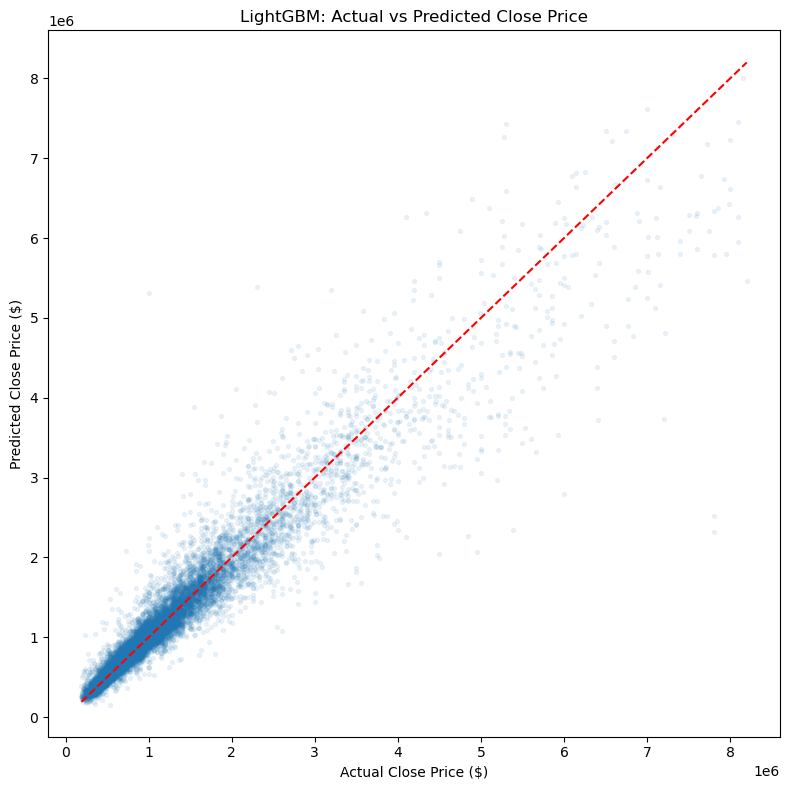

In [38]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, lgbm_test_predictions, alpha = 0.08, s = 8)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = "red",
    linestyle = "--"
)
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("LightGBM: Actual vs Predicted Close Price")
plt.tight_layout()
plt.show()

## Final Model Performance Comparison

| Model | R² | MAE | MAPE (%) | MdAPE (%) | RMSE |
|---|---:|---:|---:|---:|---:|
| Linear Regression | 0.6409 | USD 358,818.47 | 33.0190% | 24.9885% | USD 588,365.25 |
| Decision Tree Regressor | 0.8134 | USD 210,000.70 | 15.5529% | 10.1457% | USD 424,092.20 |
| Random Forest Regressor | 0.8746 | USD 168,733.01 | 12.4580% | **7.9310%** | USD 347,627.59 |
| XGBoost Regressor | 0.9009 | USD 160,000.81 | 12.5889% | 8.3710% | USD 309,013.08 |
| LightGBM Regressor | **0.9060** | **USD 156,025.13** | **12.1622%** | 8.3320% | **USD 301,065.10** |

## Advanced Model Evaluation Summary

All five models were evaluated under the same chronological train/validation/test design. XGBoost and LightGBM hyperparameters were selected using only the May 2026 validation month. After each configuration was frozen, the final model was retrained on the combined training and validation data and evaluated once on the untouched June 2026 test month.

The selected XGBoost configuration achieved validation R² of 0.9026 and test R² of 0.9009. The selected LightGBM configuration achieved validation R² of 0.9037 and test R² of 0.9060. Both models therefore remained stable across the consecutive held-out months, although validation and test metrics should not be treated as paired observations because they represent different monthly populations.

LightGBM produced the strongest final test R², MAE, MAPE, and RMSE. Compared with XGBoost, LightGBM increased R² by 0.0051, reduced MAE by USD 3,975.68, reduced MAPE by 0.4267 percentage points, reduced MdAPE by 0.0390 percentage points, and reduced RMSE by USD 7,947.98.

Compared with Random Forest, LightGBM increased R² by 0.0314, reduced MAE by USD 12,707.88, reduced MAPE by 0.2958 percentage points, and reduced RMSE by USD 46,562.49. Random Forest nevertheless retained the lowest MdAPE at 7.9310%, compared with 8.3320% for LightGBM. This means Random Forest remained slightly better for the median percentage error, while LightGBM delivered the strongest overall fit and reduced larger dollar errors more effectively.

Overall, LightGBM is the strongest current model when prioritizing R², MAE, MAPE, and RMSE. Random Forest's MdAPE advantage remains an important caveat, so the conclusion should not claim that LightGBM outperformed every model on every metric.

---------------------------------------------------------------------------------------------------------------------------------------------------------

## Author

Jasper Fan-Chiang

M.S. in Applied Data Science
University of Southern California

IDX Exchange — Data Science Internship